In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from sklearn.decomposition import PCA
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

## Load Data (excluding behavioural neurons)

In [2]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour


## Visualise Neuronal and Behavioural data

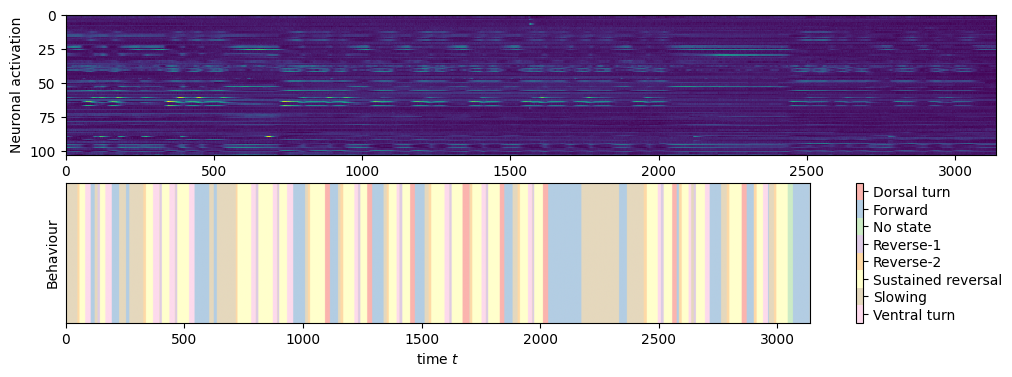

In [3]:
_, _ = plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Latent time series visualisation

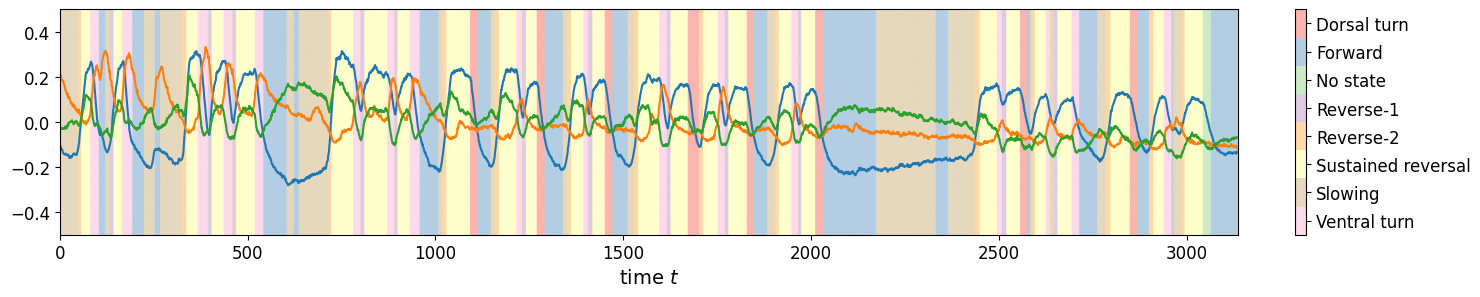

In [5]:
# To use the comparison plot we first need an embedding
pca = PCA(n_components=3)
y_pca = pca.fit_transform(x)
vis = LatentSpaceVisualiser(y_pca, b, b_names=data.behaviour_names, legend=True)
vis.plot_latent_timeseries()

## Plot phase space

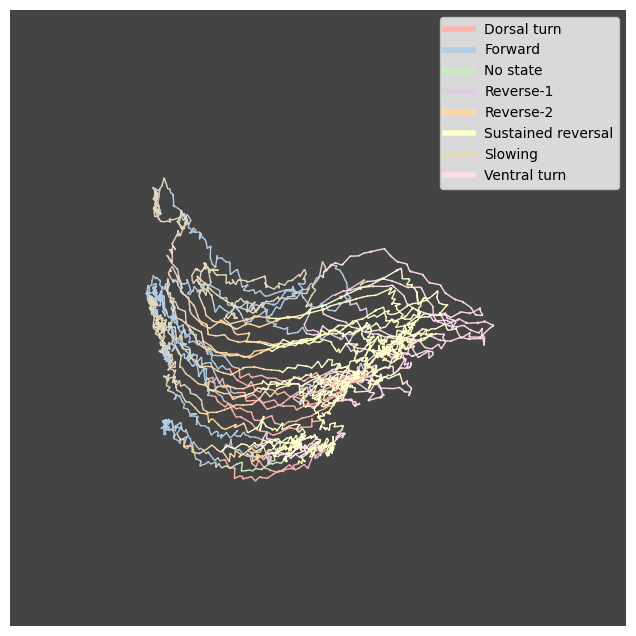

In [5]:
_, _ = vis.plot_phase_space()

## Movie Maker (GIF)

In [5]:
# Load Bundle-Net trajectory for visualisation
y = np.loadtxt('../datasets/generated/saved_embeddings/Y0__BunDLeNet_worm_0')
b = np.loadtxt('../datasets/generated/saved_embeddings/B__BunDLeNet_worm_0')

In [ ]:
# This can take quite some time to render with bigger datasets; we cut our dataset for display purposes
vis = LatentSpaceVisualiser(
    y, 
    b, 
    b_names=data.behaviour_names, 
    legend=True
)
ret = vis.make_movie(fps=30, filename='../figures/worm_0_movie.gif', show_fig=False)

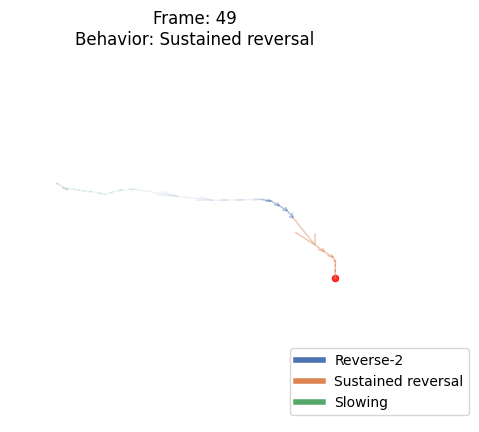

In [8]:
# The make_movie method has parameters that allow the user to fade the animation and/or add a background manifold.
ret = vis.make_movie(
    fps=30, 
    filename='../figures/worm_0_fading_movie.gif',
    show_fig=False,
    initial_alpha=0.1, # for making background manifold visible
    fade_time=10 # how many last frames will be displayed
)